<div style="display:flex; align-items:flex-start; justify-content:space-between; gap:24px; border-bottom:3px solid #8f001a; padding-bottom:16px;">
  <div>
    <h1 style="margin-bottom:0.35em;">Exercise 7: CLI-Guided Access to National Water Model Data</h1>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Faculty of Engineering, University of Ottawa</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Provided By:</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;">Professor Hossein Bonakdari</p>
    <p style="font-size:1.05em; margin:0.2em 0;">PhD Candidate Mohammad Hashtari</p>
  </div>
  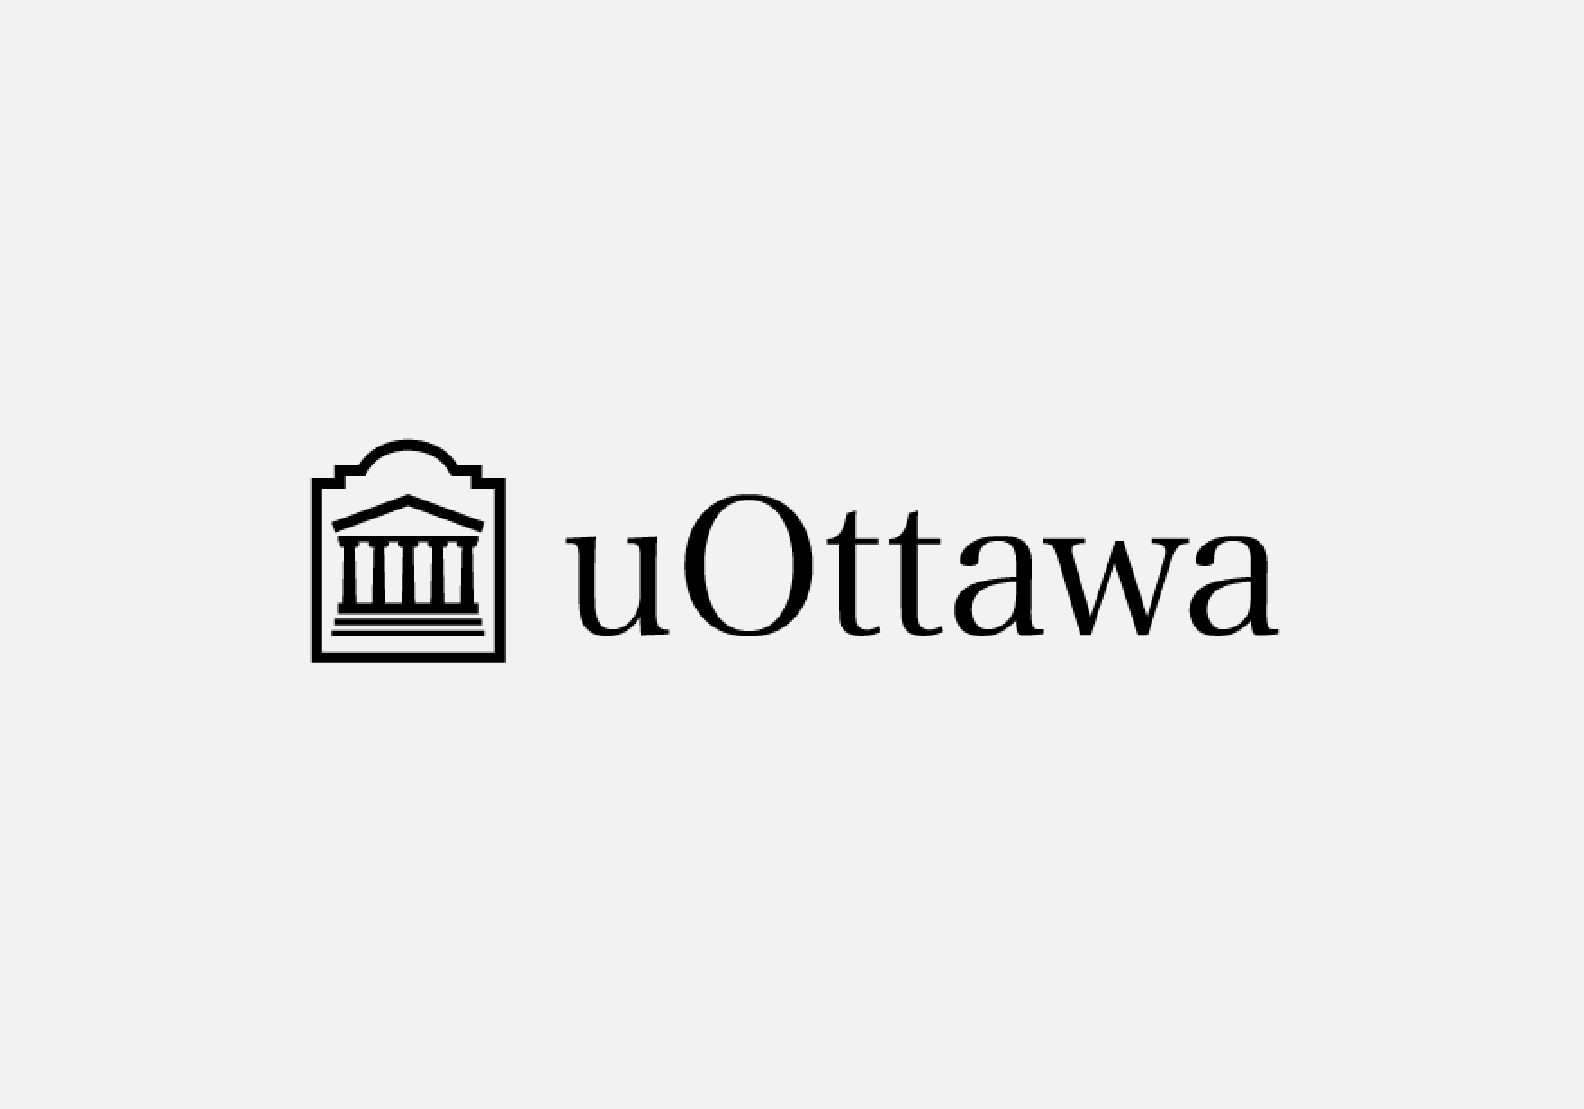
</div>

This notebook teaches how to guide an AI assistant to use an existing command-line tool safely instead of writing unnecessary API code. The hydrology example is exploratory access to NOAA National Water Model retrospective data hosted as public AWS Open Data.

In [ ]:
# Browser package setup for JupyterLite. Safe to run in local Jupyter too.
import sys

if sys.platform == "emscripten":
    import piplite
    await piplite.install(["numpy", "pandas", "matplotlib", "scipy"])


## 1. Source Basis

The data-access example is based on authoritative public-data and command-line references:

- NOAA National Water Model CONUS Retrospective Dataset, Registry of Open Data on AWS. https://registry.opendata.aws/nwm-archive/
- AWS CLI `s3 sync` command reference. https://awscli.amazonaws.com/v2/documentation/api/latest/reference/s3/sync.html
- USGS Water Mission Area catalog entry for National Water Model v2.1 output. https://water.usgs.gov/catalog/datasets/547ec566-cfd2-4ae2-ae9f-a9029bfc07f4/
- Read, L. K., et al. (2023). Restructuring and serving web-accessible streamflow data from the NOAA National Water Model historic simulations. *Scientific Data*, 10, 457. https://doi.org/10.1038/s41597-023-02316-7

Scientific note: this notebook does not download NWM data. It teaches a safe workflow for discovering public S3 data locations and previewing downloads before moving large hydrological datasets.

## 2. Learning Goal

When a robust command-line tool already exists, the assistant should learn and use that tool instead of inventing a custom wrapper. The safe workflow is:

1. Read the installed tool help.
2. Explore the remote data structure.
3. Identify the smallest relevant prefix.
4. Preview the transfer with `--dryrun`.
5. Only then prepare the real download command.

Hydrology target: plan safe access to NWM retrospective streamflow data in a public S3 bucket.

## 3. Libraries

The notebook uses Python only to document, validate, and summarize shell commands. It does not execute AWS downloads.

In [ ]:
import shutil
from pathlib import PurePosixPath

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 4. Why Use the CLI First?

For public S3 archives, the CLI is often the most transparent first tool. It can list prefixes, show object names, and preview downloads. A Python API wrapper is useful later, after the data structure is understood.

In [ ]:
approach_comparison = pd.DataFrame({
    "approach": ["custom Python wrapper first", "CLI-guided workflow first"],
    "risk": [
        "assistant guesses bucket layout, credentials, and object paths",
        "assistant discovers paths from the installed tool and remote listing",
    ],
    "researcher_control": [
        "download may start before size and scope are understood",
        "--dryrun previews transfer before data movement",
    ],
})

approach_comparison

## 5. Concept Graph

The assistant should use the tool as an exploratory instrument before writing code.

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.set_axis_off()

steps = [
    ('Help', 'Read CLI flags'),
    ('List', 'Inspect S3 prefixes'),
    ('Scope', 'Choose smallest target'),
    ('Dry Run', 'Preview transfer'),
    ('Download', 'Run only after review'),
]

x = 0.12
width = 0.76
height = 0.105
if len(steps) == 1:
    y_positions = [0.50]
else:
    y_positions = [0.78 - i * (0.66 / (len(steps) - 1)) for i in range(len(steps))]

for i, ((step_title, subtitle), y) in enumerate(zip(steps, y_positions)):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#264653",
        facecolor="#edf6f9",
        transform=ax.transAxes,
    )
    ax.add_patch(box)
    ax.text(x + 0.035, y + height * 0.64, step_title, ha="left", va="center", fontsize=11, weight="bold", transform=ax.transAxes)
    ax.text(x + 0.035, y + height * 0.30, subtitle, ha="left", va="center", fontsize=9, transform=ax.transAxes)
    if i < len(steps) - 1:
        next_y = y_positions[i + 1]
        ax.annotate(
            "", xy=(0.50, next_y + height + 0.015), xytext=(0.50, y - 0.015),
            arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#264653"},
            xycoords=ax.transAxes,
        )

ax.set_title('CLI-Guided Data Retrieval Workflow', pad=12)
plt.show()

## 6. Before and After Prompts

Weak prompt:

```text
Download NWM retrospective streamflow data for June 2011.
```

CLI-guided prompt:

```text
Use the AWS CLI, not a custom Python wrapper.
First run aws s3 ls --help and aws s3 sync --help to learn the installed flags.
Explore s3://noaa-nwm-retro-v2-zarr-pds/ with --no-sign-request.
Identify the streamflow Zarr prefix.
Prepare a dry-run sync command first. Do not run the real download until I approve the scope and size.
```

The stronger prompt makes tool use, discovery, and download safety explicit.

## 7. Local AWS CLI Check

This cell checks whether `aws` is visible to the notebook kernel. It does not call AWS.

In [ ]:
aws_cli_path = shutil.which("aws")
aws_cli_status = "available" if aws_cli_path else "not found in PATH"

pd.DataFrame([{
    "tool": "aws",
    "status": aws_cli_status,
    "path": aws_cli_path or "install AWS CLI before running shell commands",
}])

## 8. Command Plan

The command plan is explicit and reviewable. Public buckets commonly require `--no-sign-request` so the CLI does not look for private credentials.

In [ ]:
bucket = "s3://noaa-nwm-retro-v2-zarr-pds"
streamflow_prefix = f"{bucket}/chrtout.zarr/"
local_target = "../data/raw/nwm/chrtout.zarr"

commands = pd.DataFrame({
    "step": [
        "inspect list help",
        "inspect sync help",
        "list bucket root",
        "list streamflow prefix",
        "preview download",
        "real download after approval",
    ],
    "command": [
        "aws s3 ls --help",
        "aws s3 sync --help",
        f"aws s3 ls {bucket}/ --no-sign-request",
        f"aws s3 ls {streamflow_prefix} --no-sign-request",
        f"aws s3 sync {streamflow_prefix} {local_target} --dryrun --no-sign-request",
        f"aws s3 sync {streamflow_prefix} {local_target} --no-sign-request",
    ],
})

commands

## 9. Safety Checks

The notebook checks the command plan before presenting it. The real command must not include `--dryrun`, and the preview command must include it.

In [ ]:
preview_command = commands.loc[commands["step"] == "preview download", "command"].iloc[0]
real_command = commands.loc[commands["step"] == "real download after approval", "command"].iloc[0]

assert bucket in preview_command
assert "chrtout.zarr" in preview_command
assert "--dryrun" in preview_command
assert "--no-sign-request" in preview_command
assert "--dryrun" not in real_command
assert "--no-sign-request" in real_command

print("Command safety checks passed.")

## 10. Dry-Run Review

A real dry run prints the objects that would be copied. The simulated output below shows how to summarize a dry run before committing to the transfer.

In [ ]:
simulated_dryrun_output = [
    "dryrun: download s3://noaa-nwm-retro-v2-zarr-pds/chrtout.zarr/.zmetadata to ../data/raw/nwm/chrtout.zarr/.zmetadata",
    "dryrun: download s3://noaa-nwm-retro-v2-zarr-pds/chrtout.zarr/streamflow/0.0.0 to ../data/raw/nwm/chrtout.zarr/streamflow/0.0.0",
    "dryrun: download s3://noaa-nwm-retro-v2-zarr-pds/chrtout.zarr/time/0 to ../data/raw/nwm/chrtout.zarr/time/0",
]

dryrun_summary = pd.DataFrame({
    "would_download_count": [len(simulated_dryrun_output)],
    "example_source_prefix": [str(PurePosixPath("s3://noaa-nwm-retro-v2-zarr-pds/chrtout.zarr"))],
    "requires_human_review": [True],
})

dryrun_summary

## 11. Download Decision Checklist

The assistant should stop after the dry run and ask for approval if the scope is large or uncertain.

In [ ]:
decision_checklist = pd.DataFrame({
    "question": [
        "Is the prefix the smallest hydrologically relevant target?",
        "Did the dry run show object count and examples?",
        "Is the expected local directory clear?",
        "Is there enough disk space?",
        "Has the researcher approved the real download?",
    ],
    "required_before_download": [True, True, True, True, True],
})

decision_checklist

In [ ]:
print("Preview command:")
print(preview_command)
print("\nReal command, only after approval:")
print(real_command)

## 12. Hydrological Interpretation

NWM retrospective data are large, model-derived hydrological simulations. The data-access workflow should protect scientific scope as well as disk space: identify the variable, temporal period, spatial target, units, and model version before download. CLI exploration and dry runs reduce the chance of downloading the wrong model product or an unnecessarily large archive.

## 13. Summary

- Use existing CLI tools before writing custom data-access wrappers.
- Ask the assistant to read `--help` output for the installed CLI version.
- Explore public S3 prefixes with `aws s3 ls` and `--no-sign-request`.
- Use `aws s3 sync --dryrun` before any real download.
- For hydrology datasets, verify model version, variable, time period, spatial target, units, and archive size before transferring data.